# TIỀN XỬ LÝ DỮ LIỆU

Notebook này thực hiện toàn bộ quá trình tiền xử lý dữ liệu bao gồm:

1. Đọc dữ liệu gốc.
2. Khảo sát và đánh giá chất lượng dữ liệu.
3. Làm sạch dữ liệu.
4. Xây dựng các thuộc tính mới (Feature Engineering).
5. Xuất bộ dữ liệu sạch phục vụ cho bước phân tích khám phá dữ liệu và xây dựng Dashboard.

## 1. Đọc dữ liệu gốc

In [122]:
# Tắt các cảnh báo không cần thiết
import warnings
warnings.filterwarnings("ignore")

# Xử lý biểu thức chính quy
import re

# Thư viện xử lý dữ liệu
import numpy as np
import pandas as pd
from pathlib import Path

# Thư viện trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# Hiển thị đầy đủ các cột
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# Thiết lập giao diện biểu đồ
plt.style.use("ggplot")

In [123]:
# Gộp các file dữ liệu gốc
import glob

# Tìm tất cả các file CSV trong thư mục raw
csv_files = sorted(glob.glob("../raw/cat*.csv"))
print(f"Tìm thấy {len(csv_files)} file CSV:")
for f in csv_files:
    print(f"  - {Path(f).name}")

# Gộp các file CSV lại thành 1 DataFrame
df_list = [pd.read_csv(f) for f in csv_files]
df = pd.concat(df_list, ignore_index=True)

# Tách địa chỉ thành danh sách (thực hiện sớm để phục vụ điền khuyết Price ở mục 3.2)
address_parts = df["Address"].str.split(",")
df["Province"] = address_parts.apply(lambda x: x[0].strip() if isinstance(x, list) and len(x) > 0 else "Không xác định")
df["District"] = address_parts.apply(lambda x: x[1].strip() if isinstance(x, list) and len(x) > 1 else "Không xác định")
df["Detail"] = address_parts.apply(
    lambda x: ", ".join([part.strip() for part in x[2:]]) if isinstance(x, list) and len(x) > 2 else "Không xác định"
)


Tìm thấy 12 file CSV:
  - cat01_can_ho_chung_cu.csv
  - cat02_chung_cu_mini_chdv.csv
  - cat03_nha_rieng.csv
  - cat04_biet_thu_lien_ke.csv
  - cat05_nha_mat_pho.csv
  - cat06_shophouse.csv
  - cat07_dat_nen_du_an.csv
  - cat08_dat.csv
  - cat09_trang_trai_khu_nghi_duong.csv
  - cat10_condotel.csv
  - cat11_kho_nha_xuong.csv
  - cat12_bds_khac.csv


## 2. Khảo sát dữ liệu

Khảo sát tổng quan bộ dữ liệu nhằm đánh giá chất lượng dữ liệu trước khi thực hiện tiền xử lý.

### 2.1 Tổng quan bộ dữ liệu

In [124]:
print(f"Số dòng: {df.shape[0]:,}")
print(f"Số cột : {df.shape[1]}")

# Hiển thị 5 dòng đầu tiên
df.head()

Số dòng: 3,680
Số cột : 15


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Day,Province,District,Detail
0,"Hà Nội, Hà Đông, Căn hộ chung cư tại Khu đô thị mới Dương Nội",84.0,NaN,NaN,Đông,Đông - Bắc,2.0,2.0,Have certificate,Full,NaN,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Khu đô thị mới Dương Nội
1,"Hà Nội, Hà Đông, Căn hộ chung cư tại The Pride",73.0,NaN,NaN,NaN,NaN,2.0,2.0,Have certificate,Full,NaN,1,Hà Nội,Hà Đông,Căn hộ chung cư tại The Pride
2,"Quảng Ninh, Vân Đồn, Căn hộ chung cư tại Vân Bay Tower",70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Quảng Ninh,Vân Đồn,Căn hộ chung cư tại Vân Bay Tower
3,"Hồ Chí Minh, Bình Tân, Căn hộ chung cư tại Lê Thành Tân Tạo",34.0,NaN,NaN,NaN,NaN,1.0,1.0,Sale contract,NaN,0.75,1,Hồ Chí Minh,Bình Tân,Căn hộ chung cư tại Lê Thành Tân Tạo
4,"Hà Nội, Hà Đông, Căn hộ chung cư tại SDU - 143 Trần Phú",52.0,NaN,NaN,Tây - Nam,Đông - Bắc,2.0,2.0,Have certificate,Full,3.95,1,Hà Nội,Hà Đông,Căn hộ chung cư tại SDU - 143 Trần Phú


### 2.2 Danh sách các thuộc tính

In [125]:
pd.DataFrame({
    "Tên thuộc tính": df.columns
})

,Tên thuộc tính
0,Address
1,Area
2,Frontage
3,Access Road
4,House direction
5,Balcony direction
6,Bedrooms
7,Bathrooms
8,Legal status
9,Furniture state


### 2.3 Kiểm tra kiểu dữ liệu

In [126]:
# Thông tin tổng quan của bộ dữ liệu
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3680 entries, 0 to 3679
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            3680 non-null   str    
 1   Area               3680 non-null   float64
 2   Frontage           2065 non-null   float64
 3   Access Road        1838 non-null   float64
 4   House direction    1738 non-null   object 
 5   Balcony direction  880 non-null    object 
 6   Bedrooms           1738 non-null   float64
 7   Bathrooms          1683 non-null   float64
 8   Legal status       3176 non-null   str    
 9   Furniture state    1264 non-null   object 
 10  Price              3348 non-null   float64
 11  Day                3680 non-null   int64  
 12  Province           3680 non-null   str    
 13  District           3680 non-null   str    
 14  Detail             3680 non-null   str    
dtypes: float64(6), int64(1), object(3), str(5)
memory usage: 978.5+ KB


In [127]:
# Thống kê số lượng từng kiểu dữ liệu
df.dtypes.value_counts()

float64    6
str        5
object     3
int64      1
Name: count, dtype: int64

### 2.4 Kiểm tra giá trị khuyết

In [128]:
# Thống kê số lượng và tỷ lệ giá trị thiếu
missing = pd.DataFrame({
    "Số lượng thiếu": df.isnull().sum(),
    "Tỷ lệ (%)": (df.isnull().mean() * 100).round(2)
})

missing = missing[missing["Số lượng thiếu"] > 0]

missing.sort_values(
    by="Tỷ lệ (%)",
    ascending=False
)

,Số lượng thiếu,Tỷ lệ (%)
Balcony direction,2800,76.09
Furniture state,2416,65.65
Bathrooms,1997,54.27
Bedrooms,1942,52.77
House direction,1942,52.77
Access Road,1842,50.05
Frontage,1615,43.89
Legal status,504,13.70
Price,332,9.02


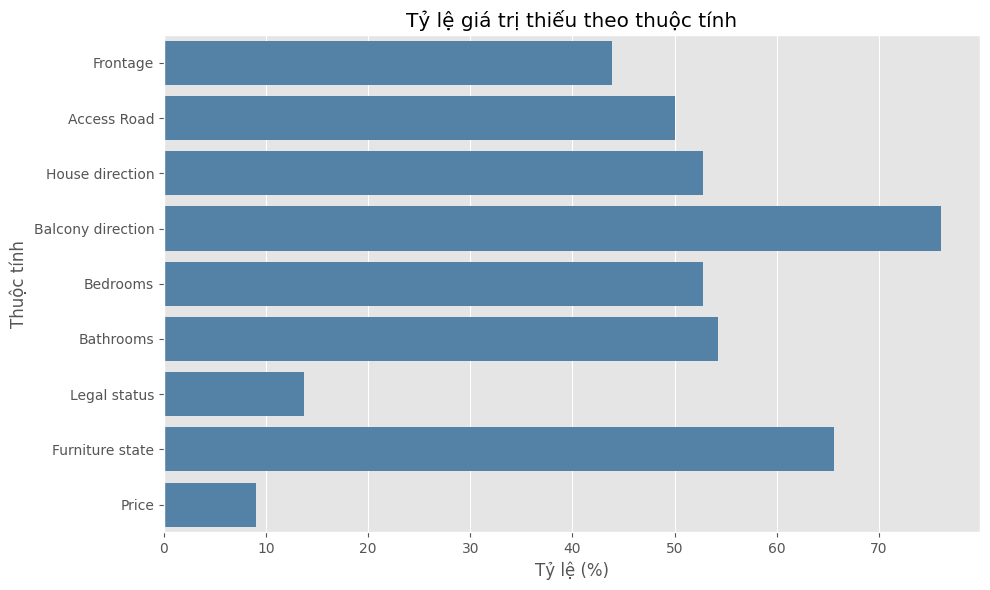

In [129]:
# Trực quan hóa tỷ lệ giá trị thiếu
plt.figure(figsize=(10,6))

sns.barplot(
    data=missing.reset_index(),
    x="Tỷ lệ (%)",
    y="index",
    color="steelblue"
)

plt.title("Tỷ lệ giá trị thiếu theo thuộc tính")
plt.xlabel("Tỷ lệ (%)")
plt.ylabel("Thuộc tính")

plt.tight_layout()
plt.show()

### 2.5 Kiểm tra dữ liệu trùng lặp

In [130]:
duplicate_count = df.duplicated().sum()

print(f"Số dòng bị trùng lặp: {duplicate_count}")

# Hiển thị các dòng bị trùng (nếu có)
if duplicate_count > 0:
    display(df[df.duplicated()].head())
else:
    print("Không phát hiện dữ liệu trùng lặp.")

Số dòng bị trùng lặp: 73


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Day,Province,District,Detail
49,"Hà Nội, Nam Từ Liêm, Căn hộ chung cư tại Vinhomes Smart City",32.00,NaN,NaN,NaN,NaN,1.0,1.0,Have certificate,Full,3.10,7,Hà Nội,Nam Từ Liêm,Căn hộ chung cư tại Vinhomes Smart City
53,"Hồ Chí Minh, Bình Thạnh, Căn hộ chung cư tại Sunwah Pearl",104.72,NaN,NaN,NaN,NaN,2.0,2.0,Sale contract,Basic,24.92,7,Hồ Chí Minh,Bình Thạnh,Căn hộ chung cư tại Sunwah Pearl
58,"Hưng Yên, Văn Giang, Căn hộ chung cư tại Alumi - Alluvia City",114.93,NaN,NaN,Bắc,Bắc,3.0,3.0,Sale contract,Basic,8.81,3,Hưng Yên,Văn Giang,Căn hộ chung cư tại Alumi - Alluvia City
85,"Hà Nội, Thanh Trì, Căn hộ chung cư tại Greenera Southmark",82.67,NaN,NaN,Bắc,Nam,2.0,2.0,Sale contract,Basic,7.76,11,Hà Nội,Thanh Trì,Căn hộ chung cư tại Greenera Southmark
86,"Hà Nội, Thanh Trì, Căn hộ chung cư tại Greenera Southmark",82.67,NaN,NaN,Bắc,Nam,2.0,2.0,Sale contract,Basic,7.76,11,Hà Nội,Thanh Trì,Căn hộ chung cư tại Greenera Southmark


### 2.6 Kiểm tra giá trị của các thuộc tính

Thống kê số lượng giá trị khác nhau của từng thuộc tính và kiểm tra các thuộc tính dạng phân loại để phát hiện các giá trị chưa đồng nhất.

In [131]:
unique_summary = pd.DataFrame({
    "Thuộc tính": df.columns,
    "Số giá trị khác nhau": df.nunique().values
})

unique_summary = unique_summary.sort_values(
    by="Số giá trị khác nhau",
    ascending=False
).reset_index(drop=True)

unique_summary

,Thuộc tính,Số giá trị khác nhau
0,Address,2668
1,Detail,2524
2,Area,1170
3,Price,779
4,District,341
5,Frontage,251
6,Access Road,85
7,Province,59
8,Bedrooms,39
9,Bathrooms,37


In [132]:
#In ra giá trị và số lượng của các thuộc tính dạng categorical, để tìm ra phương án chuẩn hóa ở phần sau
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("=" * 80)
    print(df[col].value_counts(dropna=False))
    print()

Address
Bình Dương, Dĩ An, Bán đất tại đường Quốc lộ 1K                        25
Bà Rịa Vũng Tàu, Vũng Tàu, Condotel tại The Maris Vũng Tàu             18
Hồ Chí Minh, Bình Thạnh, Căn hộ chung cư tại Vinhomes Central Park     13
Hà Nội, Hoài Đức, Căn hộ chung cư tại Chung cư The Wisteria            12
Hồ Chí Minh, Bình Chánh, Nhà biệt thự, liền kề tại Trellia Cove        12
                                                                       ..
Hồ Chí Minh, Quận 8, Loại bất động sản khác tại đường Phạm Thế Hiển     1
Hồ Chí Minh, Gò Vấp, Loại bất động sản khác tại CityLand Park Hills     1
Đà Nẵng, Sơn Trà, Loại bất động sản khác tại đường Hà Bổng              1
Đồng Nai, Biên Hòa, Loại bất động sản khác tại đường Bùi Văn Hòa        1
Hà Nội, Nam Từ Liêm, Loại bất động sản khác tại đường Phạm Hùng         1
Name: count, Length: 2668, dtype: int64

House direction
NaN           1942
Đông - Nam     416
Đông - Bắc     275
Tây - Bắc      250
Tây - Nam      203
Nam            200
Đông   

### 2.7 Thống kê mô tả

In [133]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,3680.0,2558.773954,83053.199016,4.8,70.0,100.0,218.4000,5000000.0
Frontage,2065.0,13.418053,28.352161,2.8,5.0,6.0,12.0000,800.0
Access Road,1838.0,13.554804,12.196662,1.5,6.0,10.0,16.8750,150.0
Bedrooms,1738.0,4.220944,5.363535,1.0,2.0,3.0,4.0000,70.0
Bathrooms,1683.0,3.994652,5.502402,1.0,2.0,2.0,4.0000,76.0
Price,3348.0,20.989800,69.439397,0.0,2.5,6.1,15.0625,999.0
Day,3680.0,21.969293,7.854610,1.0,19.0,24.0,27.0000,30.0


### 2.8 Phát hiện giá trị ngoại lai

In [134]:
# Lấy danh sách các thuộc tính số
numeric_cols = df.select_dtypes(include=np.number).columns

numeric_cols

Index(['Area', 'Frontage', 'Access Road', 'Bedrooms', 'Bathrooms', 'Price',
       'Day'],
      dtype='str')

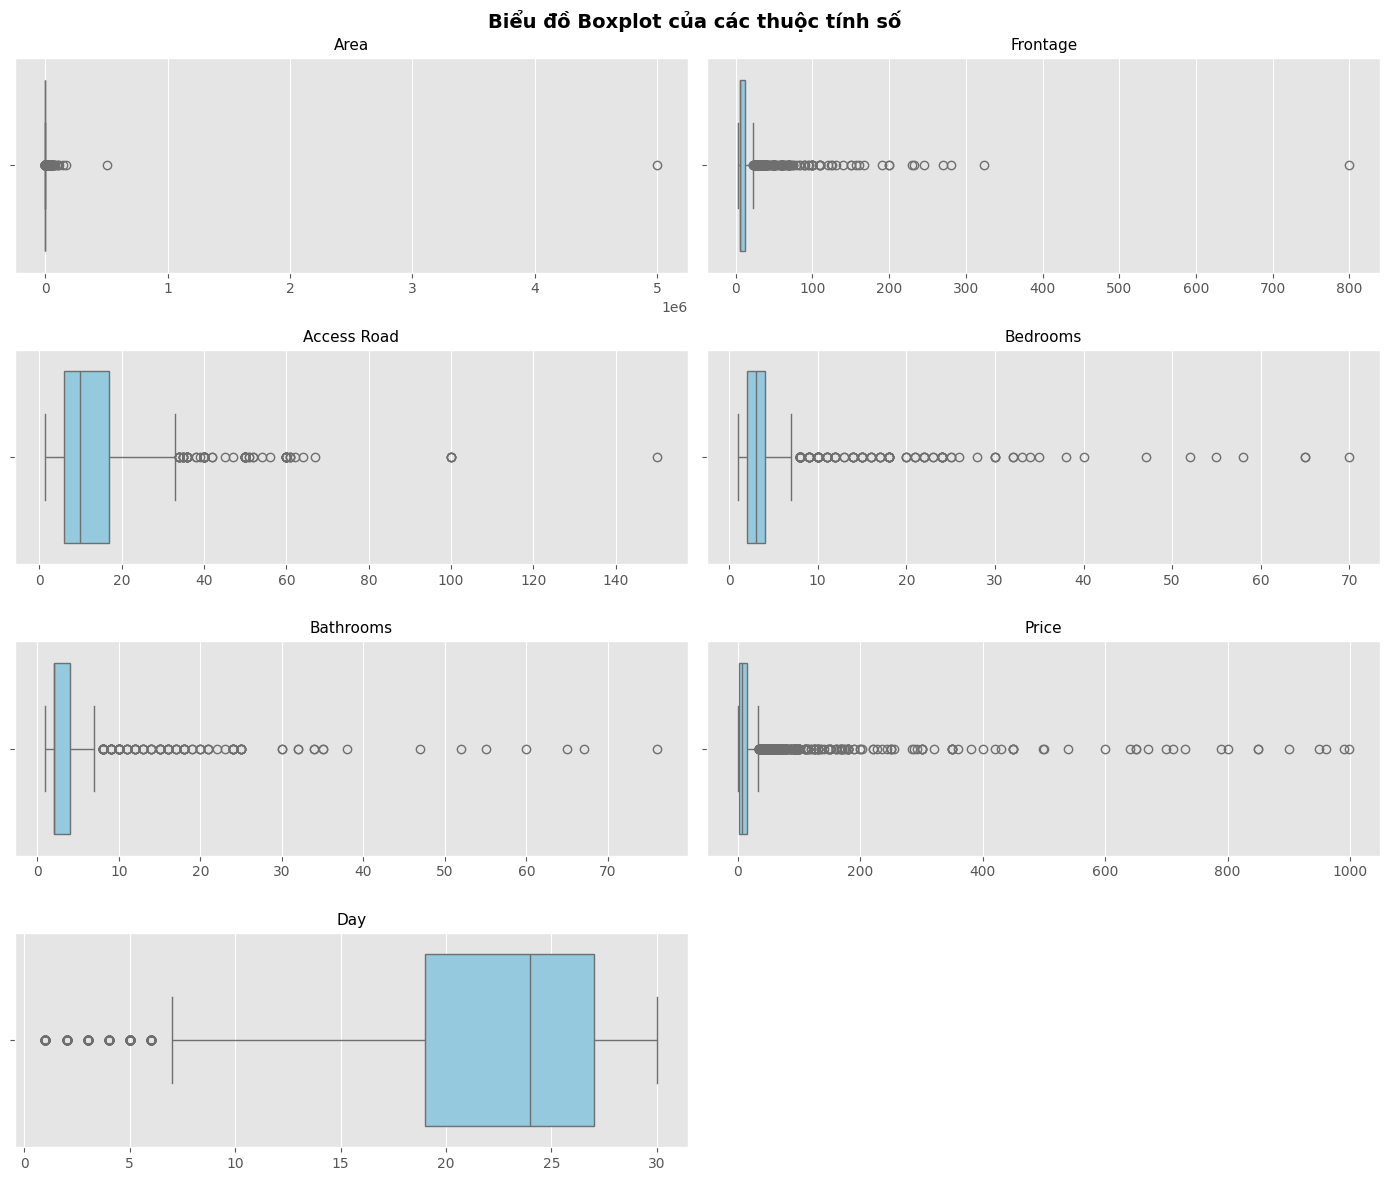

In [135]:
# Vẽ Boxplot cho các thuộc tính số theo dạng lưới 2 cột

numeric_cols = df.select_dtypes(include=np.number).columns

n_cols = 2
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 3 * n_rows)
)

# Chuyển axes thành mảng 1 chiều để dễ duyệt
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color="skyblue"
    )

    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")

# Xóa các subplot thừa (nếu số cột lẻ)
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Biểu đồ Boxplot của các thuộc tính số", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.show()

## 3. Tiền xử lý dữ liệu

### 3.1 Xử lý dữ liệu trùng lắp

In [136]:
duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Đã loại bỏ {duplicate_count} dòng dữ liệu trùng lặp.")
else:
    print("Không phát hiện dữ liệu trùng lặp.")

Đã loại bỏ 73 dòng dữ liệu trùng lặp.


### 3.2 Xử lý giá trị khuyết
- Đối với các thuộc tính dạng phân loại, các giá trị thiếu được thay thế bằng **"Không xác định"**.

- Đối với các thuộc tính dạng số, các giá trị thiếu được thay thế bằng **trung vị (Median)** nhằm giảm ảnh hưởng của các giá trị ngoại lai.

In [137]:
# Các cột phân loại
categorical_fill = {
    "House direction": "Không xác định",
    "Balcony direction": "Không xác định",
    "Legal status": "Không xác định",
    "Furniture state": "Không xác định"
}

# Thay thế giá trị thiếu của các cột phân loại
df.fillna(categorical_fill, inplace=True)

print("Đã xử lý giá trị thiếu cho các cột phân loại.")

Đã xử lý giá trị thiếu cho các cột phân loại.


In [138]:
# Các cột số cần xử lý giá trị thiếu (loại bỏ Floors)
numeric_fill = [
    "Frontage",
    "Access Road",
    "Bedrooms",
    "Bathrooms"
]

# Thay thế giá trị thiếu bằng trung vị của từng cột
for col in numeric_fill:
    df[col] = df[col].fillna(df[col].median())

print("Đã xử lý giá trị thiếu cho các cột số (Frontage, Access Road, Bedrooms, Bathrooms).")

Đã xử lý giá trị thiếu cho các cột số (Frontage, Access Road, Bedrooms, Bathrooms).


In [139]:
# Ước lượng và điền khuyết cho cột Price dựa trên đơn giá trung bình của khu vực (Quận/Huyện, Tỉnh/Thành)
df["temp_unit_price"] = df["Price"] / df["Area"]
district_means = df.groupby(["Province", "District"])["temp_unit_price"].transform("mean")
province_means = df.groupby("Province")["temp_unit_price"].transform("mean")
global_mean = df["temp_unit_price"].mean()

imputed_unit_price = district_means.fillna(province_means).fillna(global_mean)
null_price_mask = df["Price"].isna()
df.loc[null_price_mask, "Price"] = (df.loc[null_price_mask, "Area"] * imputed_unit_price).round(2)

# Xóa cột tạm
df.drop(columns=["temp_unit_price"], inplace=True, errors="ignore")

print(f"Đã ước lượng và điền khuyết cho {null_price_mask.sum()} dòng thiếu ở cột Price.")

Đã ước lượng và điền khuyết cho 319 dòng thiếu ở cột Price.


### 3.3 Chuẩn hóa dữ liệu
Thay đổi chuyển giá trị của các cột phân loại từ tiếng Anh thành tiếng Việt. 

In [140]:
# Chuẩn hóa tình trạng pháp lý
legal_mapping = {
    "Have certificate": "Đã có sổ",
    "Sale contract": "Hợp đồng mua bán"
}

df["Legal status"] = df["Legal status"].replace(legal_mapping)

print("Đã chuẩn hóa cột 'Legal status'.")

Đã chuẩn hóa cột 'Legal status'.


In [141]:
# Chuẩn hóa tình trạng nội thất
furniture_mapping = {
    "Full": "Đầy đủ",
    "Basic": "Cơ bản"
}

df["Furniture state"] = df["Furniture state"].replace(furniture_mapping)

print("Đã chuẩn hóa cột 'Furniture state'.")

Đã chuẩn hóa cột 'Furniture state'.


## 4. Xây dựng các thuộc tính mới (Feauture Engineering)

### 4.1 Tách thông tin địa chỉ

In [142]:
# Phần này đã được thực hiện trước đó để tiện cho việc điền khuyết cột Price bằng trung vị Price của huyện

# # Tách địa chỉ thành danh sách
# address_parts = df["Address"].str.split(",")

# # Tỉnh/Thành phố (phần tử đầu tiên)
# df["Province"] = address_parts.apply(lambda x: x[0].strip() if isinstance(x, list) and len(x) > 0 else "Không xác định")

# # Quận/Huyện (phần tử thứ hai)
# df["District"] = address_parts.apply(lambda x: x[1].strip() if isinstance(x, list) and len(x) > 1 else "Không xác định")

# # Chi tiết địa chỉ (các phần tử còn lại từ chỉ mục thứ hai trở đi)
# df["Detail"] = address_parts.apply(
#     lambda x: ", ".join([part.strip() for part in x[2:]]) if isinstance(x, list) and len(x) > 2 else "Không xác định"
# )

print("Đã tách địa chỉ thành các cột 'Province', 'District' và 'Detail'.")


Đã tách địa chỉ thành các cột 'Province', 'District' và 'Detail'.


### 4.2 Tạo thuộc tính mới

In [143]:
# Giá trên mỗi mét vuông
df["Price_per_m2"] = (df["Price"]/df["Area"]).round(2)

print("Đã tạo thuộc tính 'Price_per_m2'.")


Đã tạo thuộc tính 'Price_per_m2'.


### 4.4 Phân nhóm dữ liệu
Trước khi phân nhóm, tiến hành khảo sát các mốc phân vị của từng thuộc tính nhằm xác định các khoảng giá trị đại diện cho phân bố dữ liệu. Các mốc này sau đó được làm tròn thành các ngưỡng dễ hiểu để sử dụng trong Dashboard.

In [144]:
# Các mốc phân vị của diện tích
area_quantiles = df["Area"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1])

area_quantiles

0.0          4.8
0.2         65.0
0.4         90.0
0.6        125.0
0.8        300.0
1.0    5000000.0
Name: Area, dtype: float64

In [145]:
area_bins = [0, 30, 50, 70, 90, np.inf]

area_labels = [
    "<30 m²",
    "30-50 m²",
    "50-70 m²",
    "70-90 m²",
    ">90 m²"
]

df["Area_Group"] = pd.cut(
    df["Area"],
    bins=area_bins,
    labels=area_labels,
    include_lowest=True
)

print("Đã tạo thuộc tính 'Area_Group'.")

Đã tạo thuộc tính 'Area_Group'.


In [146]:
# Các mốc phân vị của giá bán
price_quantiles = df["Price"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1])

price_quantiles

0.0       0.000
0.2       1.892
0.4       4.562
0.6       8.800
0.8      19.286
1.0    5436.780
Name: Price, dtype: float64

In [147]:
price_bins = [0, 4, 6, 8, 10, np.inf]

price_labels = [
    "<4 tỷ",
    "4-6 tỷ",
    "6-8 tỷ",
    "8-10 tỷ",
    ">10 tỷ"
]

df["Price_Segment"] = pd.cut(
    df["Price"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)

print("Đã tạo thuộc tính 'Price_Segment'.")

Đã tạo thuộc tính 'Price_Segment'.


In [148]:
# Kiểm tra thông tin dữ liệu
df.info()

<class 'pandas.DataFrame'>
Index: 3607 entries, 0 to 3679
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Address            3607 non-null   str     
 1   Area               3607 non-null   float64 
 2   Frontage           3607 non-null   float64 
 3   Access Road        3607 non-null   float64 
 4   House direction    3607 non-null   object  
 5   Balcony direction  3607 non-null   object  
 6   Bedrooms           3607 non-null   float64 
 7   Bathrooms          3607 non-null   float64 
 8   Legal status       3607 non-null   str     
 9   Furniture state    3607 non-null   object  
 10  Price              3607 non-null   float64 
 11  Day                3607 non-null   int64   
 12  Province           3607 non-null   str     
 13  District           3607 non-null   str     
 14  Detail             3607 non-null   str     
 15  Price_per_m2       3607 non-null   float64 
 16  Area_Group         360

### 4.5 Chuẩn hóa lại dữ liệu sau Feature Engineering

In [149]:
df['Province'].unique()

<ArrowStringArray>
[         'Hà Nội',      'Quảng Ninh',     'Hồ Chí Minh',       'Khánh Hòa',
        'Hưng Yên',      'Bình Dương',       'Bắc Giang',       'Hải Phòng',
         'Phú Thọ',         'Đà Nẵng', 'Bà Rịa Vũng Tàu',         'Long An',
         'Cần Thơ',  'Thừa Thiên Huế',     'Thái Nguyên',        'Đồng Nai',
       'Bình Định',       'Thanh Hóa',      'Kiên Giang',       'Thái Bình',
         'Nghệ An',          'Hà Nam',       'Hải Dương',         'Bến Tre',
       'Quảng Nam',        'Hòa Bình',      'Bình Thuận',       'Vĩnh Long',
        'Tây Ninh',     'Tuyên Quang',        'Bạc Liêu',        'Lâm Đồng',
      'Bình Phước',        'Bắc Ninh',          'Cà Mau',        'Lạng Sơn',
        'An Giang',      'Tiền Giang',         'Phú Yên',         'Đắk Lắk',
      'Ninh Thuận',       'Vĩnh Phúc',        'Trà Vinh',      'Quảng Ngãi',
         'Hà Tĩnh',      'Quảng Bình',         'Lào Cai',       'Quảng Trị',
        'Nam Định',         'Yên Bái',       'Đồng Tháp',

Nhận thấy tên các tỉnh thành đã  được viết sẵn dưới nhiều dạng chuẩn thống nhất với nhau

In [150]:
df['District'].unique()

<ArrowStringArray>
[    'Hà Đông',     'Vân Đồn',    'Bình Tân',   'Thanh Trì',      'Quận 5',
     'Tân Phú',   'Nha Trang',   'Long Biên',   'Văn Giang', 'Thủ Dầu Một',
 ...
    'Nghĩa Lộ',   'Quỳnh Phụ',     'Ứng Hòa',   'Tam Dương',   'Vĩnh Long',
     'Yên Bái',      'Ba Tri',    'Vĩnh Bảo',   'Đông Hưng',  'Bình Giang']
Length: 341, dtype: str

In [151]:
# kiểm tra xem có giá trị thiếu trong cột Province không
df[df["Province"].isna()][["Address"]]

,Address


In [152]:
df[df["District"].isna()][["Address"]]

,Address


Trong quá trình tách thuộc tính `Address`, một số bản ghi không chứa đầy đủ thông tin địa chỉ (chỉ có tên đường, chỉ có quận/huyện hoặc là tiêu đề tin đăng). Đối với các trường hợp này, các thuộc tính không thể trích xuất được sẽ được gán giá trị **"Không xác định"** để đảm bảo tính nhất quán của bộ dữ liệu.

In [153]:
df["Province"] = df["Province"].replace(r"^\s*$", "Không xác định", regex=True)
df["District"] = df["District"].fillna("Không xác định")
df["Detail"] = df["Detail"].fillna("Không xác định")


### Chuẩn hóa cột District (Quận / Huyện)
Tên các quận/huyện trong dataset xuất hiện các biến thể khác nhau do tiền tố hành chính (như "Huyện", "Quận", "Thị xã", "Thành phố", "TP") hoặc cách viết hoa/thường không nhất quán (ví dụ: "Xuyên Mộc" và "Huyện Xuyên Mộc", "Thị xã Phú Mỹ" và "Thị Xã Phú Mỹ", "quận Tân Bình" và "Quận Tân Bình"). Cần chuẩn hóa về định dạng thống nhất.

In [154]:
# Chuẩn hóa tên Quận/Huyện trong cột District
import re

def clean_district(name):
    if not isinstance(name, str) or name.strip() in ("", "Không xác định", "nan"):
        return "Không xác định"
    s = name.strip()
    s = re.sub(r'\s+', ' ', s)
    # Loại bỏ các tiền tố hành chính nếu theo sau là tên tên riêng
    s_clean = re.sub(r'^(Huyện|Thị\s+[xX]ã|Quận|Thành\s+[pP]hố|TP\.?)\s+', '', s, flags=re.IGNORECASE).strip()
    
    # Nếu kết quả loại bỏ tiền tố chỉ chứa chữ số (ví dụ: '1', '2', '12'), giữ dạng 'Quận X'
    if s_clean.isdigit():
        return f"Quận {s_clean}"
    
    # Chuẩn hóa viết hoa chữ cái đầu mỗi từ
    words = s_clean.split(' ')
    s_clean = ' '.join([w.capitalize() if not w.isupper() else w for w in words])
    return s_clean

df["District"] = df["District"].apply(clean_district)
print(f"Đã chuẩn hóa cột District. Số giá trị unique sau chuẩn hóa: {df['District'].nunique()}")

Đã chuẩn hóa cột District. Số giá trị unique sau chuẩn hóa: 340


In [155]:
# Kiểm tra thông tin dữ liệu sau khi xử lý
df.info()

<class 'pandas.DataFrame'>
Index: 3607 entries, 0 to 3679
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Address            3607 non-null   str     
 1   Area               3607 non-null   float64 
 2   Frontage           3607 non-null   float64 
 3   Access Road        3607 non-null   float64 
 4   House direction    3607 non-null   object  
 5   Balcony direction  3607 non-null   object  
 6   Bedrooms           3607 non-null   float64 
 7   Bathrooms          3607 non-null   float64 
 8   Legal status       3607 non-null   str     
 9   Furniture state    3607 non-null   object  
 10  Price              3607 non-null   float64 
 11  Day                3607 non-null   int64   
 12  Province           3607 non-null   str     
 13  District           3607 non-null   str     
 14  Detail             3607 non-null   str     
 15  Price_per_m2       3607 non-null   float64 
 16  Area_Group         360

In [156]:
df.isnull().sum()

Address              0
Area                 0
Frontage             0
Access Road          0
House direction      0
Balcony direction    0
Bedrooms             0
Bathrooms            0
Legal status         0
Furniture state      0
Price                0
Day                  0
Province             0
District             0
Detail               0
Price_per_m2         0
Area_Group           0
Price_Segment        0
dtype: int64

In [157]:
df.duplicated().sum()

np.int64(0)

### 4.6 Ánh xạ tọa độ địa lý (Latitude, Longitude)

**1. Nguồn gốc của tọa độ hiện tại:**
- Các giá trị `Latitude` (Vĩ độ) và `Longitude` (Kinh độ) được tham chiếu từ **Hệ tọa độ Địa lý WGS84 (EPSG:4326)** chuẩn của **OpenStreetMap (OSM)** và **Tổng cục Thống kê (GSO)** Việt Nam.
- Mỗi Tỉnh/Thành phố được gán cặp tọa độ trọng tâm (Centroid WGS84) phục vụ hiển thị biểu đồ Choropleth Map và phân tích không gian địa lý.

In [158]:
# Bảng tọa độ vĩ độ (Latitude) và kinh độ (Longitude) trung tâm các Tỉnh/Thành phố Việt Nam
PROVINCE_COORDINATES = {
    "Hồ Chí Minh": (10.7769, 106.7009),
    "Hà Nội": (21.0285, 105.8542),
    "Bình Dương": (11.1604, 106.6508),
    "Đà Nẵng": (16.0544, 108.2022),
    "Đồng Nai": (10.9454, 106.8248),
    "Hải Phòng": (20.8449, 106.6881),
    "Khánh Hòa": (12.2388, 109.1967),
    "Hưng Yên": (20.6464, 106.0511),
    "Long An": (10.5360, 106.4099),
    "Bà Rịa Vũng Tàu": (10.4114, 107.1362),
    "Bắc Ninh": (21.1861, 106.0763),
    "Bình Thuận": (11.0904, 108.0722),
    "Lâm Đồng": (11.9404, 108.4583),
    "Quảng Ninh": (21.0069, 107.2925),
    "Cần Thơ": (10.0452, 105.7469),
    "Thanh Hóa": (19.8067, 105.7852),
    "Kiên Giang": (10.0125, 105.0809),
    "Đắc Lắc": (12.6667, 108.0500),
    "Đắk Lắk": (12.6667, 108.0500),
    "Hà Nam": (20.5453, 105.9126),
    "Bình Định": (13.7820, 109.2194),
    "Quảng Nam": (15.5667, 108.4833),
    "Hòa Bình": (20.8133, 105.3383),
    "Phú Thọ": (21.3167, 105.2167),
    "Vĩnh Phúc": (21.3083, 105.6042),
    "Lào Cai": (22.4856, 103.9707),
    "Thừa Thiên Huế": (16.4637, 107.5909),
    "Nghệ An": (19.2342, 104.8920),
    "Bắc Giang": (21.2731, 106.1946),
    "Tiền Giang": (10.4493, 106.3422),
    "Thái Bình": (20.4464, 106.3364),
    "Thái Nguyên": (21.5928, 105.8442),
    "Tây Ninh": (11.3601, 106.1098),
    "Phú Yên": (13.0882, 109.3087),
    "Ninh Thuận": (11.5653, 108.9882),
    "Hà Tĩnh": (18.3428, 105.9056),
    "Hải Dương": (20.9374, 106.3146),
    "Quảng Trị": (16.7444, 107.1855),
    "Gia Lai": (13.9833, 108.0000),
    "Bến Tre": (10.2415, 106.3758),
    "An Giang": (10.3759, 105.4185),
    "Quảng Ngãi": (15.1205, 108.7923),
    "Bình Phước": (11.7500, 106.9167),
    "Sơn La": (21.3256, 103.9188),
    "Lạng Sơn": (21.8537, 106.7610),
    "Nam Định": (20.4200, 106.1683),
    "Yên Bái": (21.7167, 104.8833),
    "Vĩnh Long": (10.2537, 105.9722),
    "Trà Vinh": (9.9347, 106.3453),
    "Đồng Tháp": (10.4578, 105.6322),
    "Cà Mau": (9.1769, 105.1500),
    "Điện Biên": (21.3833, 103.0167),
    "Sóc Trăng": (9.6033, 105.9800),
    "Ninh Bình": (20.2506, 105.9745),
    "Bạc Liêu": (9.2941, 105.7244),
    "Tuyên Quang": (21.8242, 105.2158),
    "Hà Giang": (22.8233, 104.9839),
    "Hậu Giang": (9.7844, 105.4701),
    "Quảng Bình": (17.4690, 106.6227),
    "Kon Tum": (14.3500, 108.0000),
    "Cao Bằng": (22.6667, 105.9167),
    "Lai Châu": (22.4000, 103.4500),
    "Bắc Kạn": (22.1472, 105.8347),
    "Đắk Nông": (12.2500, 107.6833),
}

df["Latitude"] = df["Province"].map(lambda p: PROVINCE_COORDINATES.get(p, (np.nan, np.nan))[0])
df["Longitude"] = df["Province"].map(lambda p: PROVINCE_COORDINATES.get(p, (np.nan, np.nan))[1])


## 5. Xuất dữ liệu sạch

In [159]:
# Đường dẫn lưu bộ dữ liệu đã tiền xử lý
output_path = "../processed/house_price_clean.csv"

# Xuất dữ liệu
df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Đã xuất dữ liệu thành công tới: {output_path}")

Đã xuất dữ liệu thành công tới: ../processed/house_price_clean.csv


In [160]:
df.info()

<class 'pandas.DataFrame'>
Index: 3607 entries, 0 to 3679
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Address            3607 non-null   str     
 1   Area               3607 non-null   float64 
 2   Frontage           3607 non-null   float64 
 3   Access Road        3607 non-null   float64 
 4   House direction    3607 non-null   object  
 5   Balcony direction  3607 non-null   object  
 6   Bedrooms           3607 non-null   float64 
 7   Bathrooms          3607 non-null   float64 
 8   Legal status       3607 non-null   str     
 9   Furniture state    3607 non-null   object  
 10  Price              3607 non-null   float64 
 11  Day                3607 non-null   int64   
 12  Province           3607 non-null   str     
 13  District           3607 non-null   str     
 14  Detail             3607 non-null   str     
 15  Price_per_m2       3607 non-null   float64 
 16  Area_Group         360

In [161]:
df.head()

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Day,Province,District,Detail,Price_per_m2,Area_Group,Price_Segment,Latitude,Longitude
0,"Hà Nội, Hà Đông, Căn hộ chung cư tại Khu đô thị mới Dương Nội",84.0,6.0,10.0,Đông,Đông - Bắc,2.0,2.0,Đã có sổ,Đầy đủ,13.81,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Khu đô thị mới Dương Nội,0.16,70-90 m²,>10 tỷ,21.0285,105.8542
1,"Hà Nội, Hà Đông, Căn hộ chung cư tại The Pride",73.0,6.0,10.0,Không xác định,Không xác định,2.0,2.0,Đã có sổ,Đầy đủ,12.00,1,Hà Nội,Hà Đông,Căn hộ chung cư tại The Pride,0.16,70-90 m²,>10 tỷ,21.0285,105.8542
2,"Quảng Ninh, Vân Đồn, Căn hộ chung cư tại Vân Bay Tower",70.0,6.0,10.0,Không xác định,Không xác định,3.0,2.0,Không xác định,Không xác định,1.54,1,Quảng Ninh,Vân Đồn,Căn hộ chung cư tại Vân Bay Tower,0.02,50-70 m²,<4 tỷ,21.0069,107.2925
3,"Hồ Chí Minh, Bình Tân, Căn hộ chung cư tại Lê Thành Tân Tạo",34.0,6.0,10.0,Không xác định,Không xác định,1.0,1.0,Hợp đồng mua bán,Không xác định,0.75,1,Hồ Chí Minh,Bình Tân,Căn hộ chung cư tại Lê Thành Tân Tạo,0.02,30-50 m²,<4 tỷ,10.7769,106.7009
4,"Hà Nội, Hà Đông, Căn hộ chung cư tại SDU - 143 Trần Phú",52.0,6.0,10.0,Tây - Nam,Đông - Bắc,2.0,2.0,Đã có sổ,Đầy đủ,3.95,1,Hà Nội,Hà Đông,Căn hộ chung cư tại SDU - 143 Trần Phú,0.08,50-70 m²,<4 tỷ,21.0285,105.8542
